# Lesson 28: TensorFlow/Keras neural network demonstration - part 1

## Introduction to TensorFlow and Keras

**TensorFlow** is an open-source numerical computation library developed by Google. It represents computations as a directed graph of operations on tensors (multi-dimensional arrays), and handles the low-level work of executing those operations efficiently on available hardware. It also provides automatic differentiation, which makes computing gradients for backpropagation automatic rather than something you have to derive by hand.

**Keras** is a high-level neural network API that ships as part of TensorFlow (`tensorflow.keras`). It sits on top of TensorFlow and provides an 'easy' interface for defining model architectures, training loops, and evaluation. In practice, you write Keras code and TensorFlow does the underlying computation.

### How the layers fit together

```text
        ┌─────────────────────────────────────┐
        │          Your Python code           │
        │    (define model, call .fit())      │
        └──────────────────┬──────────────────┘
                           │
                           ▼
        ┌─────────────────────────────────────┐
        │                Keras                │
        │   (layers, losses, optimizers,      │
        │           training loop)            │
        └──────────────────┬──────────────────┘
                           │
                           ▼
        ┌─────────────────────────────────────┐
        │        TensorFlow Python API        │
        │    (computation graph, autodiff,    │
        │             op dispatch)            │
        └──────────────────┬──────────────────┘
                           │
                           ▼
        ┌─────────────────────────────────────┐
        │       TensorFlow C++ runtime        │
        │   (compiled ops: matmul, conv,      │
        │        activations, autodiff)       │
        └──────────────────┬──────────────────┘
                           │
                           ▼
        ┌─────────────────────────────────────┐
        │           Hardware backend          │
        └──────────────────┬──────────────────┘
                  ┌────────┴────────┐
                  │                 │
                  ▼                 ▼
           ┌─────────────┐   ┌─────────────┐
           │   CUDA GPU  │   │     CPU     │
           │  (parallel  │   │ (fallback / │
           │ matrix ops) │   │small models)│
           └─────────────┘   └─────────────┘
```

When you call `model.fit()`, Keras translates your high-level instructions into TensorFlow Python API calls. Those calls are dispatched to TensorFlow's C++ runtime, where the actual numerical operations (matrix multiplications, convolutions, activation functions, and so on) are executed as compiled C++ code. The C++ runtime then hands off the work to whichever hardware backend is available: CUDA for a compatible NVIDIA GPU, or the CPU otherwise. The gradient computation for backpropagation is handled automatically by TensorFlow's autodiff engine at the C++ level, so neither you nor Keras needs to implement it explicitly.

## Notebook set up

### Vocareum compatibility

In [1]:
from pathlib import Path

# Get the parts of the current directory path as a tuple
path_parts = Path.cwd().parts

# Check if 'voc' is the first directory level
is_voc_root = len(path_parts) > 1 and path_parts[1] == "voc"

# If we are in a Vocareum instance, upgrade TensorFlow and Keras
if is_voc_root:
    print("Running in Vocareum environment")

    get_ipython().run_line_magic(
        "pip", "install -qq --no-warn-script-location tensorflow==2.17.0 keras==3.2.0"
    )

Running in Vocareum environment
Note: you may need to restart the kernel to use updated packages.


### Imports

In [ ]:
# Suppress noisy TensorFlow logs before importing
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, Model

tf.random.set_seed(315)

2026-08-26 16:51:13.952201: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-26 16:51:13.966297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-26 16:51:14.002408: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-26 16:51:14.006989: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-26 16:51:14.018982: I tensorflow/core/platform/cpu_feature_guar

### GPU configuration (if present)

In [ ]:
# Configure GPU settings
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Use only GPU 0
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpus[0], True)

        # Get GPU
        details = tf.config.experimental.get_device_details(gpus[0])
        cc = details.get('compute_capability', (0, 0))
        device = details.get('device_name', '')

        print(f'Using GPU: {device}, compute capability {cc[0]}.{cc[1]}')
        print('Memory growth enabled')

    except RuntimeError as e:
        print(e)

2026-08-26 16:51:24.023398: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 1. Data preparation

### 1.1. Load California housing data

In [4]:
housing_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/california_housing.csv')
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
label = 'MedHouseVal'
features = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']

### 1.2. Train test split

In [7]:
training_df, testing_df = train_test_split(housing_df, random_state=42)

### 1.3. Standard scale

#### Features

In [8]:
feature_scaler = StandardScaler()
feature_scaler.fit(training_df[features])

training_df[features] = feature_scaler.transform(training_df[features])
testing_df[features] = feature_scaler.transform(testing_df[features])

#### Label

In [9]:
label_scaler = StandardScaler()
label_scaler.fit(training_df[label].to_frame())

training_df[label] = label_scaler.transform(training_df[label].to_frame())
testing_df[label] = label_scaler.transform(testing_df[label].to_frame())

### 1.4. Handle outliers

In [10]:
for feature in features:

    q1 = training_df[feature].quantile(0.25)
    q3 = training_df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    training_df[feature] = training_df[feature].clip(lower=lower_bound, upper=upper_bound)
    testing_df[feature] = testing_df[feature].clip(lower=lower_bound, upper=upper_bound)

## 2. Linear regression baseline

### 2.1. Fit

In [11]:
linear_model = LinearRegression(n_jobs=-1)
fit_result = linear_model.fit(training_df[features], training_df[label])

### 2.2. Test set evaluation

In [12]:
linear_predictions = linear_model.predict(testing_df[features])
linear_rsquared = linear_model.score(testing_df[features], testing_df[label])
print(f'Linear regression R² on test set: {linear_rsquared:.4f}')

Linear regression R² on test set: 0.6586


## 3. Keras Sequential API model

The Sequential API is the simplest way to build a neural network in Keras. It allows you to create models layer-by-layer in a linear stack.

### 3.1. Build model

In [13]:
sequential_model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

sequential_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

sequential_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2. Train model

In [14]:
%%time

sequential_history = sequential_model.fit(
    training_df[features],
    training_df[label],
    epochs=75,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print('\nTraining complete.')
print(f'Final training loss: {sequential_history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {sequential_history.history["val_loss"][-1]:.4f}\n')

Epoch 1/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6672 - mae: 0.6230 - val_loss: 0.3666 - val_mae: 0.4339
Epoch 2/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3991 - mae: 0.4688 - val_loss: 0.3225 - val_mae: 0.4081
Epoch 3/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3548 - mae: 0.4382 - val_loss: 0.3072 - val_mae: 0.3968
Epoch 4/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3254 - mae: 0.4122 - val_loss: 0.2977 - val_mae: 0.3885
Epoch 5/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3170 - mae: 0.4092 - val_loss: 0.2920 - val_mae: 0.3833
Epoch 6/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3092 - mae: 0.4026 - val_loss: 0.2872 - val_mae: 0.3829
Epoch 7/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2938 - mae: 0.3919 - val_loss: 0.2850 - val_mae: 0.3780
Epoch 8/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2969 - mae: 0.3922 - val_loss: 0.2796 - val_mae: 0.3734
Epoch 9/75
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

### 3.3. Learning curves

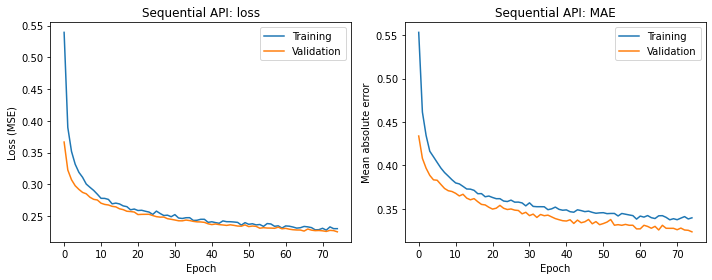

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Sequential API: loss')
axes[0].plot(sequential_history.history['loss'], label='Training')
axes[0].plot(sequential_history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(loc='best')

axes[1].set_title('Sequential API: MAE')
axes[1].plot(sequential_history.history['mae'], label='Training')
axes[1].plot(sequential_history.history['val_mae'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean absolute error')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

### 3.4. Test set evaluation

In [16]:
sequential_predictions = sequential_model.predict(testing_df[features], verbose=0).flatten()

ss_res = np.sum((testing_df[label] - sequential_predictions) ** 2)
ss_tot = np.sum((testing_df[label] - np.mean(testing_df[label])) ** 2)
sequential_rsquared = 1 - (ss_res / ss_tot)

print(f'Sequential API model R² on test set: {sequential_rsquared:.4f}')

Sequential API model R² on test set: 0.7865


### 3.5. Performance analysis

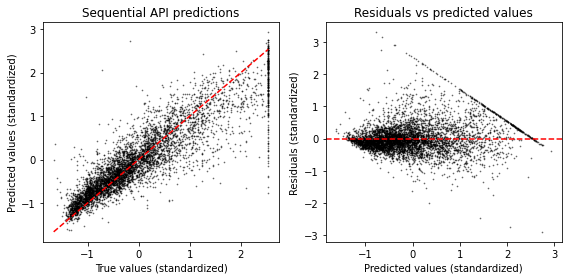

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].set_title('Sequential API predictions')
axes[0].scatter(
    testing_df[label], sequential_predictions,
    c='black', s=0.5, alpha=0.5
)
axes[0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)
axes[0].set_xlabel('True values (standardized)')
axes[0].set_ylabel('Predicted values (standardized)')

axes[1].set_title('Residuals vs predicted values')
axes[1].scatter(
    sequential_predictions, testing_df[label] - sequential_predictions,
    c='black', s=0.5, alpha=0.5
)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted values (standardized)')
axes[1].set_ylabel('Residuals (standardized)')

plt.tight_layout()
plt.show()

## 4. Keras Functional API model

The Functional API provides more flexibility than the Sequential API. It allows you to create models with non-linear topology, shared layers, and multiple inputs or outputs.

### 4.1. Build model

In [18]:
# Define input layer
inputs = keras.Input(shape=(8,), name='input_features')

# Define hidden layers
x = layers.Dense(64, activation='relu', name='hidden_1')(inputs)
x = layers.Dropout(0.2, name='dropout_1')(x)
x = layers.Dense(32, activation='relu', name='hidden_2')(x)
x = layers.Dropout(0.2, name='dropout_2')(x)

# Define output layer
outputs = layers.Dense(1, name='output')(x)

# Create model
functional_model = Model(inputs=inputs, outputs=outputs, name='functional_mlp')

functional_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

functional_model.summary()

Model: "functional_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2. Train model

In [19]:
functional_history = functional_model.fit(
    training_df[features],
    training_df[label],
    epochs=75,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print('Training complete.')
print(f'Final training loss: {functional_history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {functional_history.history["val_loss"][-1]:.4f}')

Epoch 1/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6101 - mae: 0.5943 - val_loss: 0.3551 - val_mae: 0.4213
Epoch 2/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - loss: 0.3749 - mae: 0.4537 - val_loss: 0.3120 - val_mae: 0.3960
Epoch 3/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 839us/step - loss: 0.3410 - mae: 0.4281 - val_loss: 0.3036 - val_mae: 0.3859
Epoch 4/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.3170 - mae: 0.4063 - val_loss: 0.2910 - val_mae: 0.3782
Epoch 5/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - loss: 0.3042 - mae: 0.3994 - val_loss: 0.2852 - val_mae: 0.3749
Epoch 6/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - loss: 0.2873 - mae: 0.3864 - val_loss: 0.2833 - val_mae: 0.3717
Epoch 7/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 844us/step - loss: 0.2833 - mae: 0.3813 - val_loss: 0.2719 - val_mae: 0.3667
Epoch 8/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - loss: 0.2808 - mae: 0.3791 - val_loss: 0.2700 - val_mae: 0.3658
Epoch 9/75
774/774 ━━━━━━━━━━━━━━━━━━━━ 1s

### 4.3. Learning curves

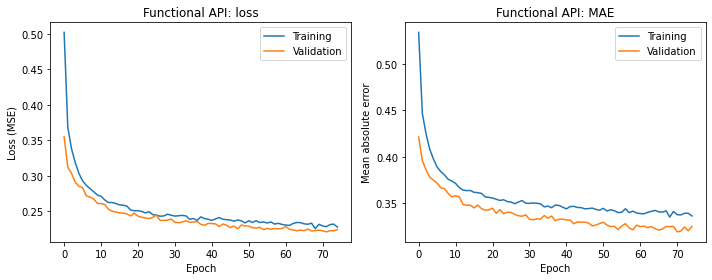

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Functional API: loss')
axes[0].plot(functional_history.history['loss'], label='Training')
axes[0].plot(functional_history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend(loc='best')

axes[1].set_title('Functional API: MAE')
axes[1].plot(functional_history.history['mae'], label='Training')
axes[1].plot(functional_history.history['val_mae'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean absolute error')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

### 4.4. Test set evaluation

In [21]:
functional_predictions = functional_model.predict(testing_df[features], verbose=0).flatten()

ss_res = np.sum((testing_df[label] - functional_predictions) ** 2)
ss_tot = np.sum((testing_df[label] - np.mean(testing_df[label])) ** 2)
functional_rsquared = 1 - (ss_res / ss_tot)

print(f'Functional API model R² on test set: {functional_rsquared:.4f}')

Functional API model R² on test set: 0.7849


### 4.5. Performance analysis

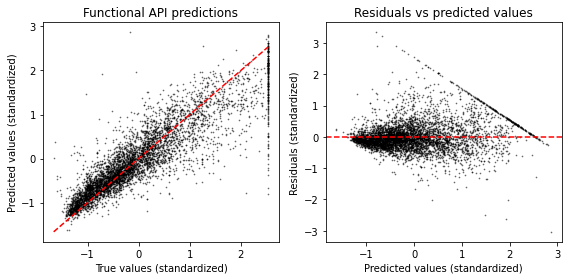

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].set_title('Functional API predictions')
axes[0].scatter(
    testing_df[label], functional_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)

axes[0].set_xlabel('True values (standardized)')
axes[0].set_ylabel('Predicted values (standardized)')

axes[1].set_title('Residuals vs predicted values')
axes[1].scatter(
    functional_predictions, testing_df[label] - functional_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted values (standardized)')
axes[1].set_ylabel('Residuals (standardized)')

plt.tight_layout()
plt.show()

## 5. Model comparison

In [23]:
print(f'Linear regression R² on test set: {linear_rsquared:.4f}')
print(f'Sequential API model R² on test set: {sequential_rsquared:.4f}')
print(f'Functional API model R² on test set: {functional_rsquared:.4f}')

Linear regression R² on test set: 0.6586
Sequential API model R² on test set: 0.7865
Functional API model R² on test set: 0.7849


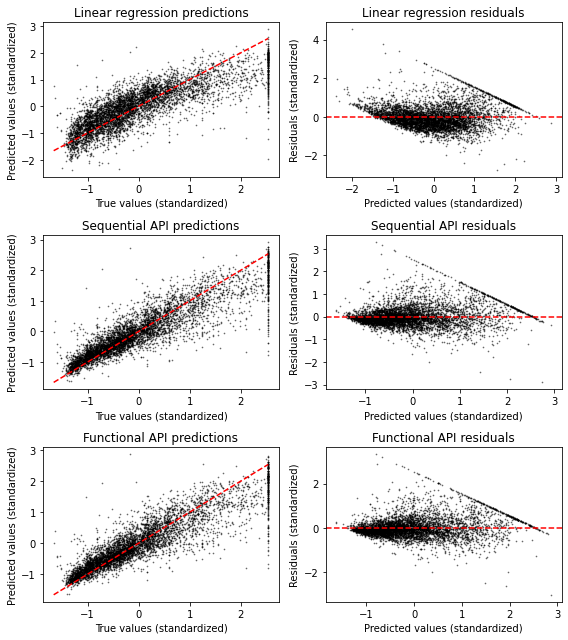

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(8, 9))

# Linear regression
axes[0, 0].set_title('Linear regression predictions')
axes[0, 0].scatter(
    testing_df[label], linear_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[0, 0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)

axes[0, 0].set_xlabel('True values (standardized)')
axes[0, 0].set_ylabel('Predicted values (standardized)')

axes[0, 1].set_title('Linear regression residuals')
axes[0, 1].scatter(
    linear_predictions, testing_df[label] - linear_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Predicted values (standardized)')
axes[0, 1].set_ylabel('Residuals (standardized)')

# Sequential API
axes[1, 0].set_title('Sequential API predictions')
axes[1, 0].scatter(
    testing_df[label], sequential_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[1, 0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)

axes[1, 0].set_xlabel('True values (standardized)')
axes[1, 0].set_ylabel('Predicted values (standardized)')

axes[1, 1].set_title('Sequential API residuals')
axes[1, 1].scatter(
    sequential_predictions, testing_df[label] - sequential_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Predicted values (standardized)')
axes[1, 1].set_ylabel('Residuals (standardized)')

# Functional API
axes[2, 0].set_title('Functional API predictions')
axes[2, 0].scatter(
    testing_df[label], functional_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[2, 0].plot(
    [testing_df[label].min(), testing_df[label].max()],
    [testing_df[label].min(), testing_df[label].max()],
    color='red', linestyle='--'
)

axes[2, 0].set_xlabel('True values (standardized)')
axes[2, 0].set_ylabel('Predicted values (standardized)')

axes[2, 1].set_title('Functional API residuals')
axes[2, 1].scatter(
    functional_predictions, testing_df[label] - functional_predictions,
    c='black', s=0.5, alpha=0.5
)

axes[2, 1].axhline(0, color='red', linestyle='--')
axes[2, 1].set_xlabel('Predicted values (standardized)')
axes[2, 1].set_ylabel('Residuals (standardized)')

plt.tight_layout()
plt.show()